# 2.k近邻算法

## 2.1 k近邻算法概述
- 简单来说，k近邻算法采用测量不同特征值之间的距离方法进行分类  
- 它的工作原理是：存在一个样本数据集合，也称作训练样本集，并且样本集中每个数据都存在标签，即我们知道样本集中每一数据与所属分类的对应关系。输入没有标签的新数据后，将新数据的每个特征与样本集中数据对应的特征进行比较，然后算法提取样本集中特征最相似数据(最近邻)的分类标签。  
- 一般只取样本数据集中前k个最相似的数据，通常k<=20。最后选择k个最相似的数据中出现次数最多的分类，作为新数据的分类。

### 2.1.1 准备：导入数据

In [ ]:
import numpy as np
import operator # 运算符模块

def createDataSet():
    # createDataSet 创建数据集和标签，
    group = np.array([[1.0,1.1], [1.0,1.0], [0,0], [0,0.1]])
    labels = ['A', 'A', 'B', 'B']
    return group, labels

group, labels = createDataSet()


In [6]:
print(group, labels, sep='\n')
print(group.shape[0])

[[1.  1.1]
 [1.  1. ]
 [0.  0. ]
 [0.  0.1]]
['A', 'A', 'B', 'B']
4


### 2.1.2 实施k近邻算法

In [ ]:
def classify0(inX, dataSet, labels, k, verbose=False):
    '''
    inX:用于分类的输入向量
    dataSet:输入的训练样本集
    labels:标签向量
    k:用于选择最近邻居的数目
    '''
    dataSetSize = dataSet.shape[0] # 计算数据集多少个样本
    diffMat = np.tile(inX, (dataSetSize, 1)) - dataSet # 将待分类的样本复制成和dataSetSize行数一样，再和其做减法得到每个特征的差值
    if verbose:
        print('diffMat——', diffMat, sep='\n')
    sqDiffMat = diffMat ** 2 # 用差值平方消除负数
    if verbose:
        print('sqDiffMat——', sqDiffMat, sep='\n')
    sqDistances = sqDiffMat.sum(axis=1) # 按行求和
    if verbose:
        print('sqDistances——', sqDistances, sep='\n')
    distances = sqDistances ** 0.5 # 开平方，得到最终距离
    if verbose:
        print('distances——', distances, sep='\n')
    sortedDistIndicies = distances.argsort() # 把距离从小到大排序，返回排序后的样本索引
    if verbose:
        print('sortedDistIndicies——', sortedDistIndicies, sep='\n')
    classCount = {}
    for i in range(k): # 取前k个样本标签，统计每个标签出现的次数
        voteIlabel = labels[sortedDistIndicies[i]] # 取出第i个距离最近的训练样本
        if verbose:
           print('voteIlabel——', voteIlabel, sep='\n')
        classCount[voteIlabel] = classCount.get(voteIlabel, 0) + 1 # 统计标签出现次数，存入字典
        # classCount[voteIlabel] = classCount.get(voteIlabel, 0) 检查对应键voteIlabel的值，如果有就取voteIlabel值+1，无就取0+1
        if verbose:
            print('classCount[voteIlabel]——', classCount[voteIlabel], sep='\n')
    sortedClassCount = sorted(classCount.items(), key=operator.itemgetter(1), reverse=True) # 把{标签:次数}的词典按列表进行次数从多到少排序
    # classCount.item():把字典{B:2,A:1}转化为键值对列表[('B',2),('A',1)]
    # key = operator.itemgetter(1)，item元素 getter(1) 获取索引为1的元素
    # reverse = True 降序
    if verbose:
        print('sortedClassCount——', sortedClassCount, sep='\n')
    return sortedClassCount[0][0] # 取出排序过后次数最多的那个标签，作为最终结果返回

In [92]:
classify0([0,0], group, labels, 3, verbose=True)

diffMat——
[[-1.  -1.1]
 [-1.  -1. ]
 [ 0.   0. ]
 [ 0.  -0.1]]
sqDiffMat——
[[1.   1.21]
 [1.   1.  ]
 [0.   0.  ]
 [0.   0.01]]
sqDistances——
[2.21 2.   0.   0.01]
distances——
[1.48660687 1.41421356 0.         0.1       ]
sortedDistIndicies——
[2 3 1 0]
voteIlabel——
B
classCount[voteIlabel]——
1
voteIlabel——
B
classCount[voteIlabel]——
2
voteIlabel——
A
classCount[voteIlabel]——
1
sortedClassCount——
[('B', 2), ('A', 1)]


'B'

### 如何使用算法
- 收集数据
- 准备数据
- 分析数据
- 训练算法
- 测试算法
- 使用算法

### 2.2.1准备数据

In [30]:
def file2matrix(filename):
    with open(filename, encoding='utf-8') as fr:
        arrayOLines = fr.readlines() # 把文件每一行都读出来，形成一个列表

    numberOfLines = len(arrayOLines) # 统计文件有多少行
    returnMat = np.zeros((numberOfLines, 3)) # 建立一个行数=numberOfLines，3列的全零数组
    classLabelVector = []
    index = 0

    for line in arrayOLines:
        line = line.strip() # 去掉每行首尾空格换行符
        listFromLine = line.split('\t') # 按制符表将一行拆分成列表
        returnMat[index, :] = listFromLine[0:3] # 把前3个数据放到数组的第index行
        # returnMat[index, :] 第index行所有列赋值为listFromLine当前行挑选前三条信息
        classLabelVector.append(int(listFromLine[-1]))
        # 取listFromLine列表最后一个元素赋值为整数加在classLabelVector
        index += 1
    return returnMat, classLabelVector

In [35]:
import os
import sys
print(os.getcwd())
current_dir = os.path.join(os.path.dirname(os.getcwd()), 'res', 'machinelearninginaction', 'Ch02')
testSet = os.path.join(current_dir, 'datingTestSet2.txt')

datingDataMat, datingLabels = file2matrix(testSet)

c:\Users\13218\Documents\GitHub\self-test-improvement\Machine_Learning\Machine_Learning_in_Action


In [32]:
datingDataMat

array([[4.0920000e+04, 8.3269760e+00, 9.5395200e-01],
       [1.4488000e+04, 7.1534690e+00, 1.6739040e+00],
       [2.6052000e+04, 1.4418710e+00, 8.0512400e-01],
       ...,
       [2.6575000e+04, 1.0650102e+01, 8.6662700e-01],
       [4.8111000e+04, 9.1345280e+00, 7.2804500e-01],
       [4.3757000e+04, 7.8826010e+00, 1.3324460e+00]], shape=(1000, 3))

In [33]:
datingLabels[0:20]

[3, 2, 1, 1, 1, 1, 3, 3, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 2, 3]

### 2.2.2 分析数据

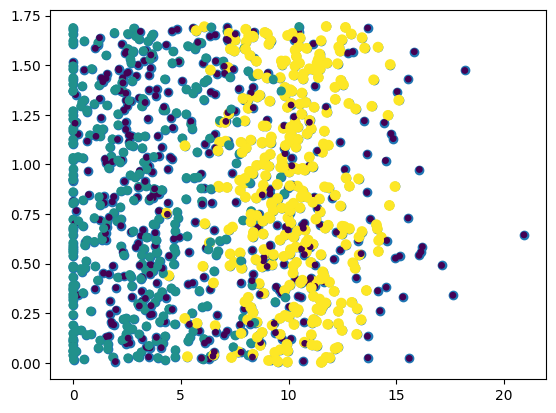

In [39]:
import matplotlib
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(datingDataMat[:,1], datingDataMat[: ,2])
ax.scatter(datingDataMat[:, 1], datingDataMat[:, 2], 15.0*np.array(datingLabels), 15.0*np.array(datingLabels))
plt.show()

### 2.2.3 准备数据:归一化数值
newValue = $\frac{oldValue-min}{max-min}$

In [66]:
def autoNorm(dataSet, verbose=False):
    if verbose:
        print(dataSet)
    minVals = dataSet.min(0) # 计算数据集中每一列最小值
    if verbose:
        print('minVals', minVals)
    maxVals = dataSet.max(0) # 计算数据集中每一列最大值
    if verbose:
        print('maxVals', maxVals)
    ranges = maxVals - minVals # 每一列取值范围
    normDataSet = np.zeros(np.shape(dataSet)) # 创建和数据集形状相同的全零数组
    m = dataSet.shape[0] # 获取数据集中的行数
    if verbose:
        print('np.tile(minVals, (m,1))——',np.tile(minVals, (m,1)),sep='\n')
        print()
        print('np.tile(ranges, (m,1))——',np.tile(ranges, (m,1)), sep='\n')
    normDataSet = dataSet - np.tile(minVals, (m,1)) # oldValue-min
    normDataSet = normDataSet/np.tile(ranges, (m,1)) # oldValue-min/max-min
    return normDataSet, ranges, minVals

In [68]:
normMat, ranges, minVals = autoNorm(datingDataMat, verbose=True)

[[4.0920000e+04 8.3269760e+00 9.5395200e-01]
 [1.4488000e+04 7.1534690e+00 1.6739040e+00]
 [2.6052000e+04 1.4418710e+00 8.0512400e-01]
 ...
 [2.6575000e+04 1.0650102e+01 8.6662700e-01]
 [4.8111000e+04 9.1345280e+00 7.2804500e-01]
 [4.3757000e+04 7.8826010e+00 1.3324460e+00]]
minVals [0.       0.       0.001156]
maxVals [9.1273000e+04 2.0919349e+01 1.6955170e+00]
np.tile(minVals, (m,1))——
[[0.       0.       0.001156]
 [0.       0.       0.001156]
 [0.       0.       0.001156]
 ...
 [0.       0.       0.001156]
 [0.       0.       0.001156]
 [0.       0.       0.001156]]

np.tile(ranges, (m,1))——
[[9.1273000e+04 2.0919349e+01 1.6943610e+00]
 [9.1273000e+04 2.0919349e+01 1.6943610e+00]
 [9.1273000e+04 2.0919349e+01 1.6943610e+00]
 ...
 [9.1273000e+04 2.0919349e+01 1.6943610e+00]
 [9.1273000e+04 2.0919349e+01 1.6943610e+00]
 [9.1273000e+04 2.0919349e+01 1.6943610e+00]]


In [ ]:
def datingClassTest():
    hoRatio = 0.10 # 设置测试集比例
    datingDataMat, datingLabels = file2matrix(testSet) # 加载数据集，将文本数据集转化为特征矩阵(datingDataMat)和标签向量(datingLabels)
    normMat, ranges, minVals = autoNorm(datingDataMat) # 特征归一化
    m = normMat.shape[0] # 获取总样本数
    numTestVecs = int(m*hoRatio) # 测试集数量=总样本数乘测试集比例
    errorCount = 0.0 # 初始化测试数量
    for i in range(numTestVecs):
        classifierResult = classify0(
            normMat[i,:],  # 第i个测试样本的特征(i行所有列)
            normMat[numTestVecs:m,:], # 训练集特征(后90%的样本)
            datingLabels[numTestVecs:m], # 训练集标签(后90%样本的真实分类)
            3)
        print(f'the classifier came back with: {classifierResult}, the real answer is: {datingLabels[i]}')
        if (classifierResult != datingLabels[i]): # 如果分类结果与真实标签不一样
                errorCount +=1
    print(f'the total error rate is {errorCount/float(numTestVecs)}')

In [73]:
datingClassTest()

the classifier came back with: 3, the real answer is: 3
the classifier came back with: 2, the real answer is: 2
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 3, the real answer is: 3
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 2, the real answer is: 2
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answer is: 1
the classifier came back with: 1, the real answe

### 2.3手写系统

In [75]:
def img2vector(filename):
    returnVect = np.zeros((1,1024))
    with open(filename,encoding='utf-8') as fr:
        for i in range(32):
            lineStr = fr.readline()
            for j in range(32):
                returnVect[0, 32*i+j] = int(lineStr[j])
        return returnVect

In [83]:
FileDir = os.path.join(current_dir, 'digits', 'testDigits')
testVector = img2vector(os.path.join(FileDir, '0_13.txt'))
testVector[0, 0:31]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
from os import listdir
def handwritingClassTest(verbose=False):
    '''训练'''
    hwLabels = [] # 空列表存储每个训练样本的真实数字

    trainingFileList = listdir(FileDir) # 获取指定目录下所有配置文件
    if verbose:
        print(trainingFileList)
    m = len(trainingFileList) # 统计训练文件总数
    if verbose:
        print(m)
    trainingMat = np.zeros((m,1024)) # 创建m行1024列全0矩阵 m代表有m行存m个样本的特征 每个特征有32x32即1024像素
    for i in range(m):
        fileNameStr = trainingFileList[i] # 从文件列表获取当前第i个文件名称
        fileStr = fileNameStr.split('.')[0] # 去掉txt后缀，如(3_12.txt→3_12)
        classNumStr = int(fileStr.split('_')[0]) # 从文件名如(3_12)获取第一个数字3
        hwLabels.append(classNumStr) # 真实数字添加到标签列表
        
        trainingMat[i,:] = img2vector(os.path.join(FileDir, fileNameStr)) # 将全零矩阵第i行所有列替换为img2vector返回fileName的1024维特征向量

    '''测试'''
    testFileList = listdir(FileDir)        #iterate through the test set
    errorCount = 0.0
    mTest = len(testFileList) # 统计测试文件总数
    for i in range(mTest):
        fileNameStr = testFileList[i]
        fileStr = fileNameStr.split('.')[0]     #take off .txt
        classNumStr = int(fileStr.split('_')[0])
        
        vectorUnderTest = img2vector(os.path.join(FileDir, fileNameStr)) # 将测试图片转为1024维向量
        classifierResult = classify0(vectorUnderTest, trainingMat, hwLabels, 3) # 得到预测结果
        if not verbose:
            print(f'the classifier came back with: {classifierResult}, the real answer is: {classNumStr}')
        if (classifierResult != classNumStr): errorCount += 1.0
    if not verbose:
        print(f'\nthe total number of errors is: {int(errorCount)}')
    if not verbose:
        print(f'\nthe total error rate is: {errorCount/float(mTest)}')

In [91]:
handwritingClassTest(verbose=True)

['0_0.txt', '0_1.txt', '0_10.txt', '0_11.txt', '0_12.txt', '0_13.txt', '0_14.txt', '0_15.txt', '0_16.txt', '0_17.txt', '0_18.txt', '0_19.txt', '0_2.txt', '0_20.txt', '0_21.txt', '0_22.txt', '0_23.txt', '0_24.txt', '0_25.txt', '0_26.txt', '0_27.txt', '0_28.txt', '0_29.txt', '0_3.txt', '0_30.txt', '0_31.txt', '0_32.txt', '0_33.txt', '0_34.txt', '0_35.txt', '0_36.txt', '0_37.txt', '0_38.txt', '0_39.txt', '0_4.txt', '0_40.txt', '0_41.txt', '0_42.txt', '0_43.txt', '0_44.txt', '0_45.txt', '0_46.txt', '0_47.txt', '0_48.txt', '0_49.txt', '0_5.txt', '0_50.txt', '0_51.txt', '0_52.txt', '0_53.txt', '0_54.txt', '0_55.txt', '0_56.txt', '0_57.txt', '0_58.txt', '0_59.txt', '0_6.txt', '0_60.txt', '0_61.txt', '0_62.txt', '0_63.txt', '0_64.txt', '0_65.txt', '0_66.txt', '0_67.txt', '0_68.txt', '0_69.txt', '0_7.txt', '0_70.txt', '0_71.txt', '0_72.txt', '0_73.txt', '0_74.txt', '0_75.txt', '0_76.txt', '0_77.txt', '0_78.txt', '0_79.txt', '0_8.txt', '0_80.txt', '0_81.txt', '0_82.txt', '0_83.txt', '0_84.txt', 